# SAR Image Generation Demo

This notebook demonstrates the SAR back-projection pipeline:
1. Load a labeled collection (JSON config + raw ADC data)
2. Generate SAR images via GPU-accelerated batched FFT convolution
3. Visualize amplitude, phase, and H/V polarimetric ratio

In [1]:
# %matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')
from polysight.dsp.sar import calc_sar_fromfile
from polysight.utils.io import load_label_json, load_sar_pair, save_sar
from polysight.eval.visualization import visualize_sar, make_sar_figure

## Configuration

Set `labels_dir` to the directory containing your labeled collections.

In [ ]:
labels_dir = '../data/labels/'
collection_name = '20250612_142257_multi'
radar_list = ['RH', 'RV']

## Generate SAR from raw ADC data (currently requires CuPy running on GPU)

In [6]:
# Requires raw ADC data accessible via fileDir in the collection JSON.
label_dict, sar_list = calc_sar_fromfile(
    collection_name, radar_list,
    sum_bins=True, chunk_size=0,
    labels_dir=labels_dir,
    base_dir='..')

sar_h, sar_v = sar_list
print(f'SAR shape: {sar_h.shape}')

  RH: 0.86s, shape (150, 150)
  RV: 0.65s, shape (150, 150)
SAR shape: (150, 150)


In [25]:
# # Save generated SAR images as .npy for future use
# for radar_name, sar in zip(radar_list, sar_list):
#     path = save_sar(sar, radar_name, collection_name, labels_dir)
#     print(f'Saved: {path}')

## Or, you can also use pre-calculated SAR images

In [4]:
# If SAR images were previously saved as .npy files:
sar_h, sar_v = load_sar_pair(collection_name, labels_dir)
label_dict = load_label_json(collection_name, labels_dir)
print(f'SAR shape: {sar_h.shape}')
print(f'Labels: {list(label_dict.get("labels", {}).keys())}')

SAR shape: (150, 150)
Labels: ['rubber', 'cardboard_rough', 'silicone_rubber', 'PET_0.5mm', 'ceramic', 'acrylic_3mm', 'PCB', 'copper', 'wood_thin']


## Visualize SAR images

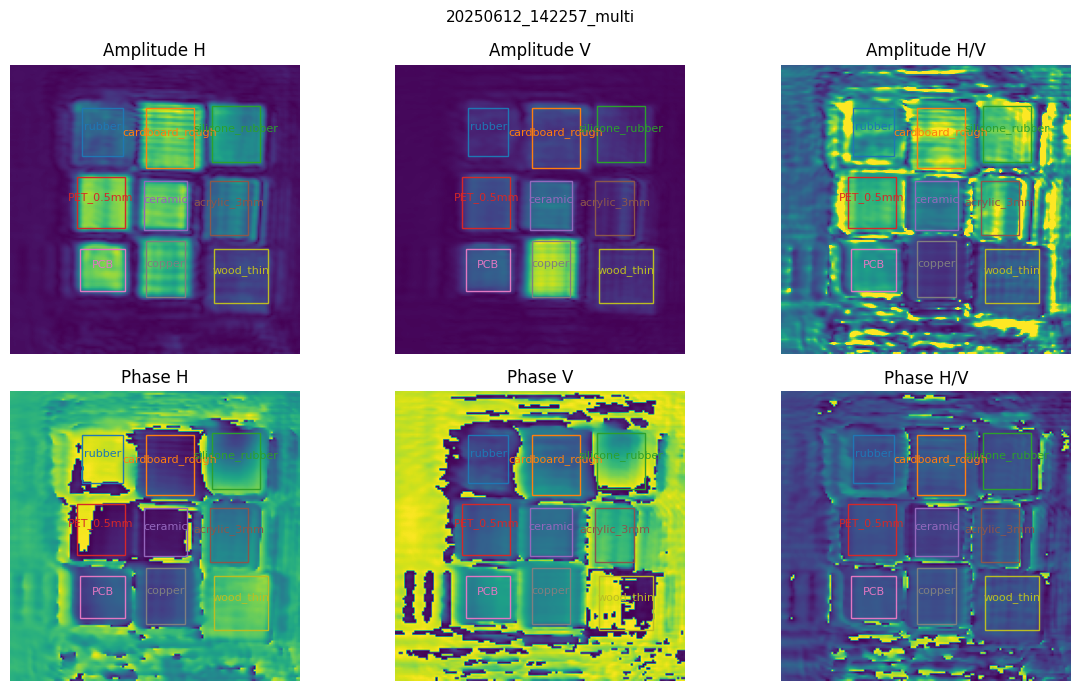

In [7]:
labels = label_dict.get('labels', {})
fig = visualize_sar(
    [sar_h, sar_v], radar_list,
    labels=labels,
    title=collection_name,
    vmax_ratio=5)
plt.show()